# ¡Hola Vanessa! 😊

Mi nombre es **Alejandro Castellanos** y hoy voy a continuar el proceso de revisión realizado por **Dot**. A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**



<div class="alert alert-block alert-success">
<b>Comentario General del revisor (3ra Iteración)</b> <a class=“tocSkip”></a>

¡Vanessa excelente trabajo con los ajustes! Tu proyecto ahora cumple con todos los objetivos propuestos. Estoy seguro de que lo que aprendiste aquí te será muy útil más adelante. 

¡Éxito en tu próximo sprint! 🚀

*Estado del Proyecto:* **Aprobado**

</div>

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [5]:
# Cargar todas las librerías

import numpy as np

import pandas as pd
from math import factorial
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar datos

In [6]:
calls = pd.read_csv("D:/Documents/Data_analisys/Sprint_5/megaline_calls.csv")
messages = pd.read_csv("D:/Documents/Data_analisys/Sprint_5/megaline_messages.csv")
internet = pd.read_csv("D:/Documents/Data_analisys/Sprint_5/megaline_internet.csv")
users = pd.read_csv("D:/Documents/Data_analisys/Sprint_5/megaline_users.csv")
plans = pd.read_csv("D:/Documents/Data_analisys/Sprint_5/megaline_plans.csv")


## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [7]:

# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [8]:
# Imprime una muestra de los datos para las tarifas
plans.head(10)


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

CALIDAD DE LOS DATOS:

1. Consistencia: diferencia de unidades mb_per_month_included y se cobra en gb(usd_per_gb)

2. Presicion : No existen duplicados

3. Completitud: No se evidencian ausentes 


TIPO DE PLAN:
#Ultimate 70 USD
#Surf 20 USD

#veces más caro = Precio_ultimate / Precio_surf
Ultimate es 3.5 veces más caro que Surf
Aunque el plan Ultimate cuesta 3.5 veces más, en varias categorías entrega mucho más que eso:

20× más mensajes

6× más minutos

2× más MB

El plan Ultimate da mucho más valor por dólar, el único punto en que no es claramente superior es el MB por dólar, (usd_per_gb)


Aunque los tipos numéricos son correctos (int64 y float64), algunos valores monetarios (usd_monthly_pay y usd_per_gb ) podrían representarse como float para mayor flexibilidad en cálculos futuros.


El precio por consumo extra está definido en USD por GB (usd_per_gb).
Por lo tanto, el consumo incluido en cada plan debe estar en la misma unidad (GB) para aplicar correctamente la tarifa.La estandarización de unidades es una regla básica en limpieza de datos y previene errores silenciosos que pueden afectar las conclusiones.



## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [9]:
plans['usd_monthly_pay'] = plans['usd_monthly_pay'].astype(float)
plans['usd_per_gb'] = plans['usd_per_gb'].astype(float)

## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [10]:
#segamentar planes
plans['is_high_data_plan'] = plans['mb_per_month_included'] > plans['mb_per_month_included'].median()
plans['is_premium_plan'] = plans['usd_monthly_pay'] > plans['usd_monthly_pay'].median()

## Usuarios/as

In [11]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [12]:
# Imprime una muestra de datos para usuarios
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

1. La columna churn_date  y regd_date debe ser cambiado el tipo de dato , str a datetime usando pd.to_datetime().

2. El resto de columnas parecen tener tipos de datos adecuados.
No existen filas duplicadas ni IDs de usuario repetidos, lo cual indica buena precisión e integridad del identificador principal.

3.Todas las columnas tienen 0 valores nulos, excepto: churn_date 466 valores nulos, el valor NaN en churn_date indica que el usuario no ha cancelado el servicio, mantener los NaN ya que son informativos.


### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [13]:
#Calidad .Precision
users.duplicated().sum()
users.duplicated('user_id').sum()

#Calidad: Completitud
users.isna().sum()

#type data: str -> datatime
users['churn_date'] = pd.to_datetime(users['churn_date'])
users['reg_date'] = pd.to_datetime(users['reg_date'])

users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [14]:
#Cuántos días llevaba el cliente activo hasta el final del periodo de análisis (2018).
users['customer_lifetime_days'] = (
    (pd.to_datetime('2019-01-01') - users['reg_date']).dt.days
)

users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,customer_lifetime_days
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,8
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,141
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,72
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,338
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,223
...,...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaT,119
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaT,315
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaT,22
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaT,331


## Llamadas

In [15]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()
calls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72
137731,1499_200,1499,2018-10-20,10.89
137732,1499_201,1499,2018-09-21,8.12
137733,1499_202,1499,2018-10-10,0.37


In [16]:
# Imprime una muestra de datos para las llamadas
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Hallazgo principal: es el tipo de dato de call_date, que está definido como object en lugar de datetime.
No se identifican datos ausentes, ya que todas las columnas tienen el mismo número de valores no nulos

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [17]:
#type data: str -> datatime
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls.info()

calls.duplicated().sum()
calls.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


id           0
user_id      0
call_date    0
duration     0
dtype: int64

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

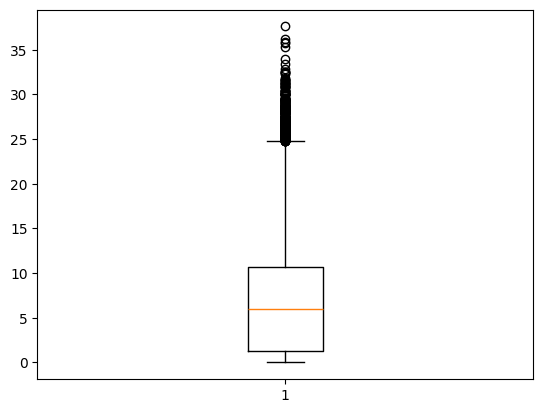

In [18]:
#Para facturación o análisis mensual, normalmente se requiere redondear hacia arriba la duración de las llamadas.
#calls['duration'] = np.ceil(calls['duration'])
#calls

calls.describe()
#la llamada promedio es de 6.7
#todo lo que este por debajo de 10min son el 75% d elos datos
#max son 37min , es decir de 10min a 37min esta el 25% de los datos
#std los datos estan separados por 5.8min

calls['duration'].std()

plt.boxplot(calls['duration'])
plt.show()



## Mensajes

In [19]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [20]:
# Imprime una muestra de datos para los mensajes
messages.head()


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

La columna message_date contiene fechas en formato YYYY-MM-DD; sin embargo, está almacenada como tipo object

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [21]:
messages['message_date']= pd.to_datetime(messages['message_date'])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [22]:
##type data: str -> datatime
messages['message_date']= pd.to_datetime(messages['message_date'])

#gregar nueva columna mensajes por mes
messages['mes']=messages['message_date'].dt.to_period('M').astype(str)
messages

,id,user_id,message_date,mes
0,1000_125,1000,2018-12-27,2018-12
1,1000_160,1000,2018-12-31,2018-12
2,1000_223,1000,2018-12-31,2018-12
3,1000_251,1000,2018-12-27,2018-12
4,1000_255,1000,2018-12-26,2018-12
...,...,...,...,...
76046,1497_526,1497,2018-12-24,2018-12
76047,1497_536,1497,2018-12-24,2018-12
76048,1497_547,1497,2018-12-31,2018-12
76049,1497_558,1497,2018-12-24,2018-12


## Internet

In [23]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [24]:
# Imprime una muestra de datos para el tráfico de internet
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

No se identifican valores ausentes.

session date esta almacenada como tipo object.  

los megabytes (mb_used) usados por usuario estan almacenados por día (session date), se pueden tanto redondear como sumar para ver los mb_used al final del mes.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [25]:
internet['session_date']= pd.to_datetime(internet['session_date'])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [26]:
internet['mes'] = internet['session_date'].dt.to_period('M').astype(str)

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Excelente trabajo en el análisis preliminar de los datasets. Usaste correctamente las funciones `info` y `head` para revisar la estructura y el contenido de los datos, lo que te permitió realizar los ajustes necesarios. Esto facilitará el análisis de los datos y el desarrollo de las demás etapas del proyecto.


</div>

## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [27]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,is_high_data_plan,is_premium_plan
0,50,15360,500,20.0,10.0,0.03,0.03,surf,False,False
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,True,True


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [28]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

calls['mes'] = calls['call_date'].dt.to_period('M').astype(str)

calls_usage = calls.groupby(['user_id', 'mes'])['call_date'].count().reset_index()
calls_usage



,user_id,mes,call_date
0,1000,2018-12,16
1,1001,2018-08,27
2,1001,2018-09,49
3,1001,2018-10,65
4,1001,2018-11,64
...,...,...,...
2253,1498,2018-12,39
2254,1499,2018-09,41
2255,1499,2018-10,53
2256,1499,2018-11,45


In [29]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
#calls_usage = calls.groupby(['user_id', 'mes'])['duration'].sum().reset_index()

calls_usage = calls.groupby(['user_id', 'mes']).agg(minutos_consumidos=('duration','sum') ,numero_llamadas=('duration', 'count')).reset_index()
calls_usage

,user_id,mes,minutos_consumidos,numero_llamadas
0,1000,2018-12,116.83,16
1,1001,2018-08,171.14,27
2,1001,2018-09,297.69,49
3,1001,2018-10,374.11,65
4,1001,2018-11,404.59,64
...,...,...,...,...
2253,1498,2018-12,324.77,39
2254,1499,2018-09,330.37,41
2255,1499,2018-10,363.28,53
2256,1499,2018-11,288.56,45


In [30]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

#gregar nueva columna mensajes por mes

messages['mes']=messages['message_date'].dt.to_period('M').astype(str)

#Total mensajes enviados por usuario al mes
messages_sent = messages.groupby(['user_id','mes']).agg(messages_sent=('message_date','count')).reset_index()
messages_sent



,user_id,mes,messages_sent
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36
...,...,...,...
1801,1496,2018-09,21
1802,1496,2018-10,18
1803,1496,2018-11,13
1804,1496,2018-12,11


In [31]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_usage = internet.groupby(['user_id','mes'])['mb_used'].sum().reset_index()
#Redondear decimales
internet_usage['mb_used'] = np.ceil(internet_usage['mb_used'])
internet_usage


,user_id,mes,mb_used
0,1000,2018-12,1902.0
1,1001,2018-08,6920.0
2,1001,2018-09,13315.0
3,1001,2018-10,22331.0
4,1001,2018-11,18505.0
...,...,...,...
2272,1498,2018-12,23138.0
2273,1499,2018-09,12985.0
2274,1499,2018-10,19493.0
2275,1499,2018-11,16814.0


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [32]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

analytics_megaline = calls_usage.merge(internet_usage, on = ['user_id', 'mes'])
analytics_megaline = analytics_megaline.merge(messages_sent, on = ['user_id', 'mes'])
analytics_megaline

,user_id,mes,minutos_consumidos,numero_llamadas,mb_used,messages_sent
0,1000,2018-12,116.83,16,1902.0,11
1,1001,2018-08,171.14,27,6920.0,30
2,1001,2018-09,297.69,49,13315.0,44
3,1001,2018-10,374.11,65,22331.0,53
4,1001,2018-11,404.59,64,18505.0,36
...,...,...,...,...,...,...
1754,1496,2018-09,389.94,52,16390.0,21
1755,1496,2018-10,301.16,46,14288.0,18
1756,1496,2018-11,291.88,39,8548.0,13
1757,1496,2018-12,278.61,40,16439.0,11


In [33]:
# Añade la información de la tarifa
analytics_megaline = analytics_megaline.merge(users, on =['user_id'])
analytics_megaline = analytics_megaline.merge(plans, left_on='plan', right_on='plan_name')

analytics_megaline


,user_id,mes,minutos_consumidos,numero_llamadas,mb_used,messages_sent,first_name,last_name,age,city,...,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,is_high_data_plan,is_premium_plan
0,1000,2018-12,116.83,16,1902.0,11,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",...,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,True,True
1,1001,2018-08,171.14,27,6920.0,30,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,False,False
2,1001,2018-09,297.69,49,13315.0,44,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,False,False
3,1001,2018-10,374.11,65,22331.0,53,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,False,False
4,1001,2018-11,404.59,64,18505.0,36,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754,1496,2018-09,389.94,52,16390.0,21,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,False,False
1755,1496,2018-10,301.16,46,14288.0,18,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,False,False
1756,1496,2018-11,291.88,39,8548.0,13,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,False,False
1757,1496,2018-12,278.61,40,16439.0,11,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,False,False


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [34]:
# Calcula el ingreso mensual para cada usuario
def calcular_pago(row):
  pago = row['usd_monthly_pay']

  if (row['minutos_consumidos'] >  row['minutes_included']): # Corrected column name
    pago +=  (row['minutos_consumidos'] - row['minutes_included']) * row['usd_per_minute']

  if (row['mb_used'] > row['mb_per_month_included']):
    pago += np.ceil((row['mb_used'] - row['mb_per_month_included'])/1024) * row['usd_per_gb']

  if (row['messages_sent'] > row['messages_included']):
    pago += (row['messages_sent'] - row['messages_included']) * row['usd_per_message']

  return pago


In [35]:
analytics_megaline['pago'] = analytics_megaline.apply(calcular_pago, axis =1)
analytics_megaline

,user_id,mes,minutos_consumidos,numero_llamadas,mb_used,messages_sent,first_name,last_name,age,city,...,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,is_high_data_plan,is_premium_plan,pago
0,1000,2018-12,116.83,16,1902.0,11,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",...,30720,3000,70.0,7.0,0.01,0.01,ultimate,True,True,70.00
1,1001,2018-08,171.14,27,6920.0,30,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,15360,500,20.0,10.0,0.03,0.03,surf,False,False,20.00
2,1001,2018-09,297.69,49,13315.0,44,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,15360,500,20.0,10.0,0.03,0.03,surf,False,False,20.00
3,1001,2018-10,374.11,65,22331.0,53,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,15360,500,20.0,10.0,0.03,0.03,surf,False,False,90.09
4,1001,2018-11,404.59,64,18505.0,36,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,15360,500,20.0,10.0,0.03,0.03,surf,False,False,60.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754,1496,2018-09,389.94,52,16390.0,21,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",...,15360,500,20.0,10.0,0.03,0.03,surf,False,False,40.00
1755,1496,2018-10,301.16,46,14288.0,18,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",...,15360,500,20.0,10.0,0.03,0.03,surf,False,False,20.00
1756,1496,2018-11,291.88,39,8548.0,13,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",...,15360,500,20.0,10.0,0.03,0.03,surf,False,False,20.00
1757,1496,2018-12,278.61,40,16439.0,11,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",...,15360,500,20.0,10.0,0.03,0.03,surf,False,False,40.00


<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

¡Perfecto Vanessa! Hiciste un excelente uso de las funciones `groupby`  y `merge`, logrando agrupar correctamente la información de consumo de llamadas, mensajes e internet de cada usuario por mes, inclusive considerando las condiciones de redondeo. Además, calculaste de manera precisa el cobro mensual y reflejaste los valores correctos en la columna *pago*. ¡Buen trabajo!

</div>

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

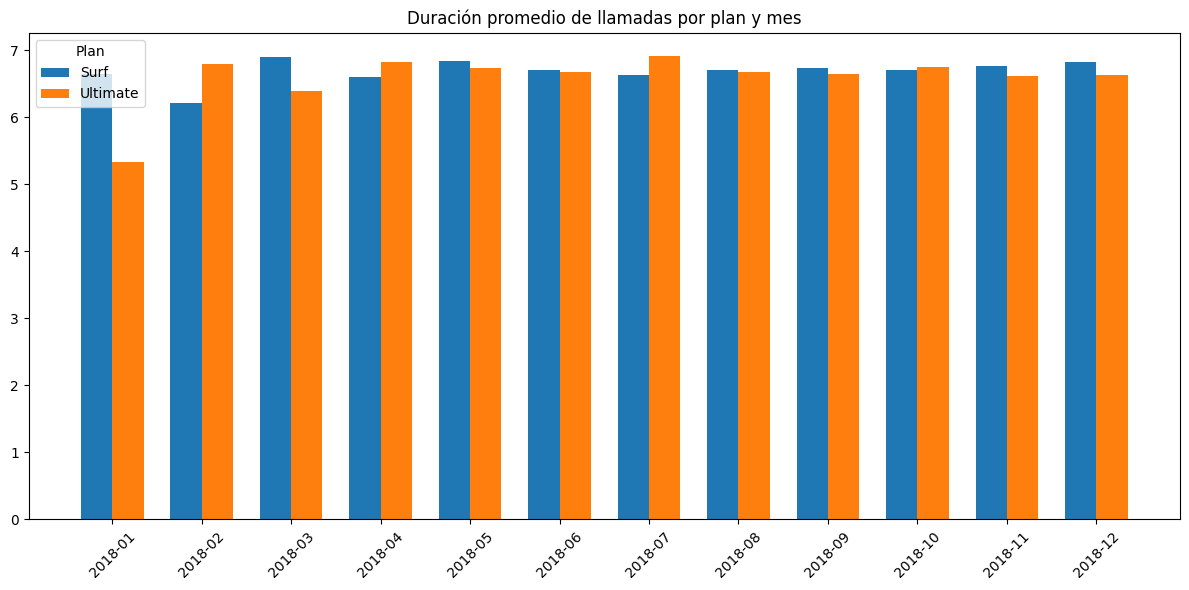

In [36]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

#duracion_promedio = numero_llamadas/minutos_consumidos

# Duración promedio de llamada por usuario_mes
analytics_megaline['calls_mean_per_user'] = (
    analytics_megaline['minutos_consumidos'] /
    analytics_megaline['numero_llamadas']
)


avg_duration_plan_month = (
analytics_megaline.groupby(['plan','mes'])['calls_mean_per_user']).mean().reset_index()
months = avg_duration_plan_month['mes'].unique()

x = np.arange(len(months)) #posciones de los meses
width = 0.35 #ancho de las barras

#Filtar por 'plan'
plan1 = avg_duration_plan_month[avg_duration_plan_month['plan'] == 'surf']
plan2 = avg_duration_plan_month[avg_duration_plan_month['plan'] == 'ultimate']

plt.figure(figsize=(12,6))

#grafico/ barras plan surf
plt.bar(
    x - width/2,
    plan1['calls_mean_per_user'],
    width=width,
    label='Surf'
)

#grafico/ barras plan ultimate
plt.bar(
    x + width/2,
    plan2['calls_mean_per_user'],
    width=width,
    label='Ultimate'
)

plt.xlabel=('Mes')
plt.ylabel=('Duración promedio de llamadas (minutos)')
plt.title('Duración promedio de llamadas por plan y mes')
plt.xticks(x, months, rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Para este tipo de gráficos debes evitar sobreponer las columnas, ya que hay datos que no se logran ver. Es mejor si configuras las columnas una al lado de la otra, de esta forma, la información será más clara de ver y de interpretar. Algo como la siguiente imagen:

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20210216005002/Multiplebarcharts1.png" width="400">

En este enlace puedes ver una explicación de cómo se puede crear este tipo de gráficos: [Enlace](https://www.geeksforgeeks.org/python/plotting-multiple-bar-charts-using-matplotlib-in-python/)

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (3ra Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo con los ajustes, ahora la gráfica es más clara de analizar

</div>

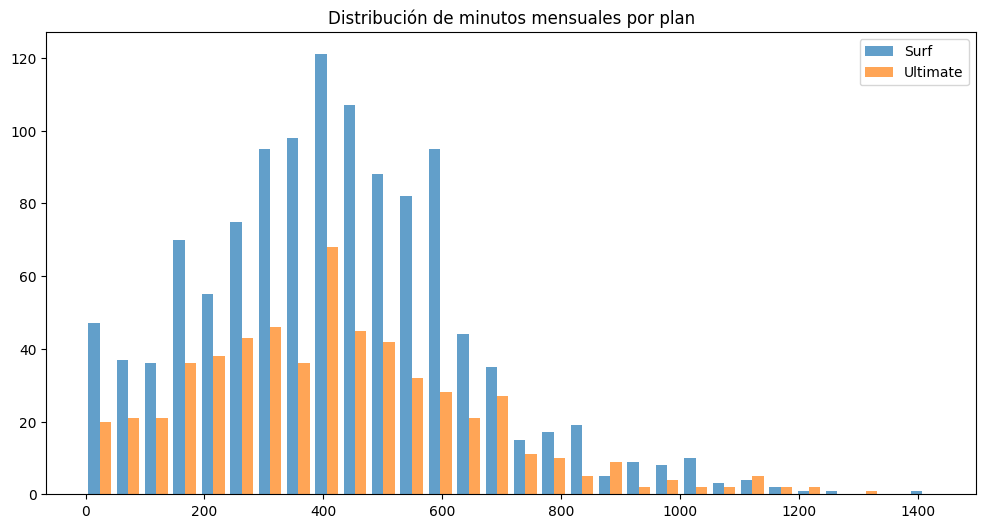

In [37]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
plan_surf_minutos = analytics_megaline[analytics_megaline['plan'] == 'surf']['minutos_consumidos']
plan_ultimate_minutos = analytics_megaline[analytics_megaline['plan'] == 'ultimate']['minutos_consumidos']

plan_surf_minutos = analytics_megaline[analytics_megaline['plan'] == 'surf']['minutos_consumidos']
plan_ultimate_minutos = analytics_megaline[analytics_megaline['plan'] == 'ultimate']['minutos_consumidos']

plt.figure(figsize=(12, 6))
plt.hist([plan_surf_minutos, plan_ultimate_minutos], bins=30, alpha=0.7, label=['Surf', 'Ultimate'])
plt.xlabel = ('Minutos consumidos por mes')
plt.ylabel = ('Número de usuarios')
plt.title('Distribución de minutos mensuales por plan')
plt.legend()
plt.show()


[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [38]:
# Calcula la media y la varianza de la duración mensual de llamadas.

mean= analytics_megaline['minutos_consumidos'].sum()/analytics_megaline['minutos_consumidos'].count()
mean

np.float64(419.7197839681637)

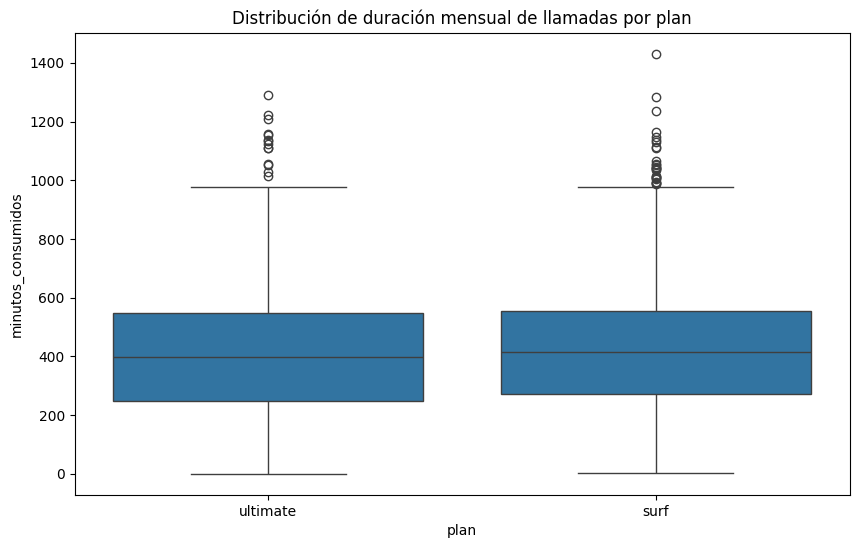

In [39]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
plt.figure(figsize=(10,6))
sns.boxplot(data= analytics_megaline, x='plan' , y='minutos_consumidos')
plt.title('Distribución de duración mensual de llamadas por plan')
plt.xlabel = ('plan')
plt.ylabel =('minutos consumidos por mes')
plt.show()


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

Ultimate ofrece 3000 minutos y Surf solo 500 minutos, el boxplot muestra que La mediana de consumo es muy similar en ambos planes (≈400–420 minutos).

Los minutos adicionales de Ultimate no parecen ser el factor principal de valor del plan.

En ambos planes existen usuarios con consumos muy altos (outliers)en Surf, estos usuarios probablemente exceden el límite de 500 minutos y generan cargos adicionales, en Ultimate, esos mismos perfiles quedan cubiertos por el plan.

A pesar de que el plan Ultimate incluye seis veces más minutos que Surf (3000 vs 500), el consumo mensual de llamadas es muy similar en ambos grupos. Esto indica que el comportamiento de los usuarios no varía significativamente según el plan, y que la mayoría no aprovecha el límite ampliado de Ultimate. El valor de este plan parece concentrarse en un grupo reducido de usuarios de alto consumo, mientras que para el usuario promedio, Surf cubre adecuadamente sus necesidades de llamadas.

### Mensajes


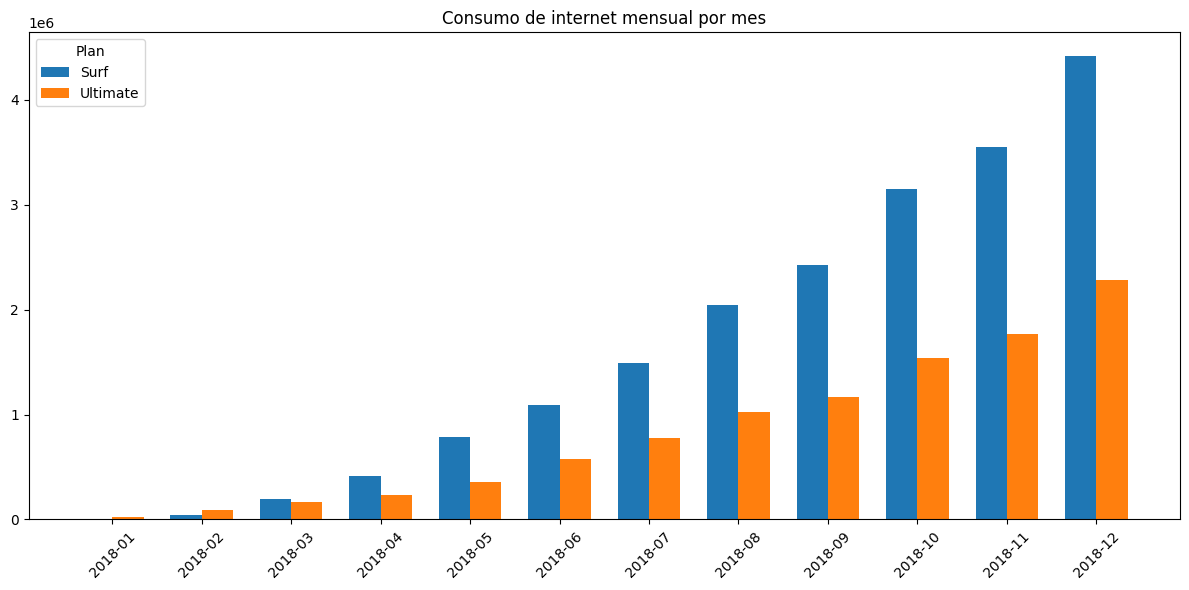

In [40]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
mb_per_plan_month = analytics_megaline.groupby(['plan', 'mes'])['mb_used'].sum().reset_index()


months = avg_duration_plan_month['mes'].unique()
x = np.arange(len(months))
width = 0.35


plan1 =  mb_per_plan_month[mb_per_plan_month['plan'] == 'surf']
plan2 =  mb_per_plan_month[mb_per_plan_month['plan']== 'ultimate']


plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    plan1['mb_used'],
    width=width,
    label='Surf'
)

plt.bar(
    x + width/2,
    plan2['mb_used'],
    width=width,
    label='Ultimate'
)

plt.xlabel=('Mes')
plt.ylabel=('mb')
plt.title('Consumo de internet mensual por mes')
plt.xticks(x, months, rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()



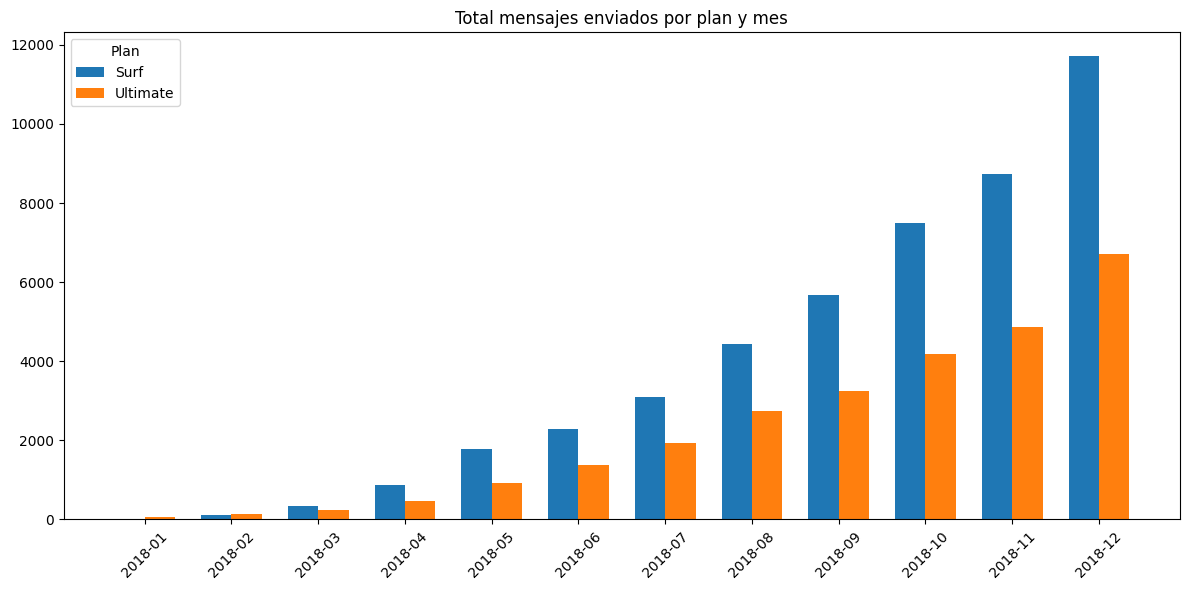

In [41]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
messages_per_plan_month = analytics_megaline.groupby(['plan', 'mes'])['messages_sent'].sum().reset_index()

months = avg_duration_plan_month['mes'].unique()
x = np.arange(len(months))
width = 0.35

plan1 = messages_per_plan_month[messages_per_plan_month['plan'] == 'surf']
plan2 = messages_per_plan_month[messages_per_plan_month['plan'] == 'ultimate']

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    plan1['messages_sent'],
    width=width,
    label='Surf'
)

plt.bar(
    x + width/2,
    plan2['messages_sent'],
    width=width,
    label='Ultimate'
)
plt.xlabel=('Mes')
plt.ylabel=('Numero de mesajes')
plt.title('Total mensajes enviados por plan y mes')
plt.xticks(x, months, rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()




Se observa una tendencia creciente mes a mes tanto en el plan Surf como en Ultimate y en la mayoría de los meses, el plan Surf registra más mensajes totales que Ultimate.

El análisis del uso de mensajes muestra que el comportamiento de los usuarios es similar en ambos planes. Aunque el volumen total de mensajes es mayor en Surf, la tendencia de crecimiento es evidente en ambos planes lo que indica que el uso de SMS no varía de forma significativa en función del plan contratado. El envío de mensajes parece depender más de la cantidad de usuarios y de sus hábitos individuales que de las caracteristicas del plan.

### Internet

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

Contrario a lo que podría esperarse, el plan Surf muestra un volumen total de consumo de Internet superior al de Ultimate en la mayoría de los meses, el consumo del plan Ultimate se mantiene elevado y crece de forma constante a lo largo del tiempo. Este comportamiento sugiere que los usuarios de Ultimate realizan un uso más intensivo del servicio, lo que indica que el comportamiento de los usuarios si varia en funcion del plan contratado.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [42]:
income_mean = analytics_megaline.groupby('plan')['pago'].mean()
print('Ingreso promedio por plan:')
print (income_mean)


Ingreso promedio por plan:
plan
surf        60.009735
ultimate    72.248705
Name: pago, dtype: float64


In [43]:

income_per_plan = analytics_megaline.groupby('plan')['pago'].describe()
print(income_per_plan)



           count       mean        std   min   25%       50%   75%       max
plan                                                                        
surf      1180.0  60.009735  53.439458  20.0  20.0  40.73065  80.0  588.6372
ultimate   579.0  72.248705  11.034406  70.0  70.0  70.00000  70.0  182.0000


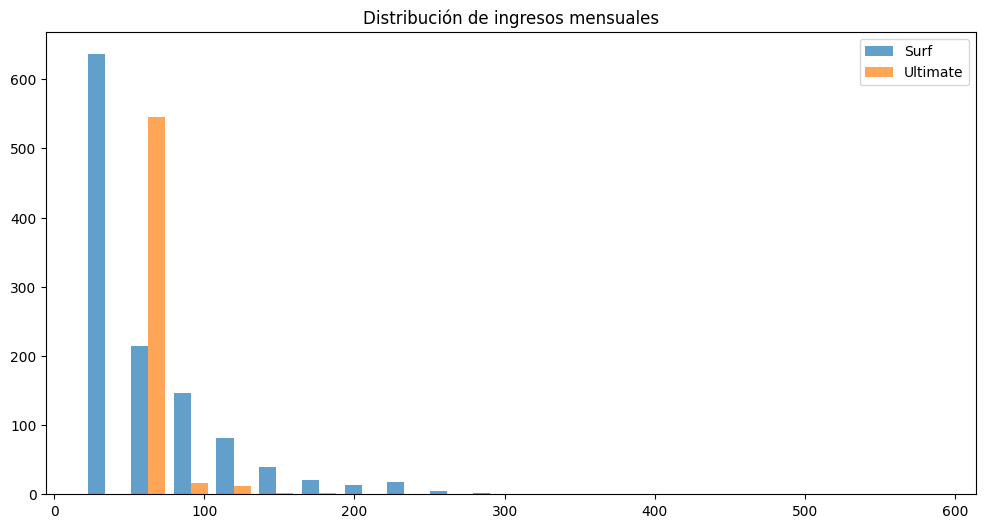

In [44]:
surf_income = analytics_megaline[analytics_megaline['plan']=='surf']['pago']
ultimate_income = analytics_megaline[analytics_megaline['plan']=='ultimate']['pago']

plt.figure(figsize=(12,6))
plt.hist([surf_income,ultimate_income],bins=20, alpha=0.7, label=['Surf', 'Ultimate'])
plt.xlabel=('Ingresos mensuales por plan')
plt.ylabel=('Número de usuarios')
plt.title ('Distribución de ingresos mensuales')
plt.legend()
plt.show()

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes

La distribución de Ultimate es más concentrada hay menos valores extremos, lo que sugiere que los usuarios rara vez exceden los límites incluidos, generando su vez ingresos más estables. La distribución de ingreos del plan Surf presenta mayor dispersión asociada a cargos adicionales lo que sugiere que los usuarios exceden rara vez los limites incluidos, dado que la mayoria de ingresos tambien se agrupan en un rango estrecho.


<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo con las visualizaciones de datos. Además, calculaste correctamente la información estadística de cada distribución de datos, tanto para el consumo de minutos, mensajes e internet, como para los ingresos asociados a los cobros mensuales en cada plan. Esto permite identificar patrones de comportamiento en los usuarios y extraer información valiosa para la compañía.

</div>

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [45]:
# Prueba las hipótesis
# H0:Ultimate=Surf
#Los ingresos promedio del plan Ultimate y del plan Surf son iguales.
#H1:Ultimate =Surf
#Los ingresos promedio del plan Ultimate y del plan Surf son diferentes.

from scipy import stats


alpha = 0.05

#Prueba t de Welch
t_stat, p_value = stats.ttest_ind(
    ultimate_income,
    surf_income,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Se rechaza la hipótesis nula: los ingresos promedio son diferentes.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia de diferencia.")




t-statistic: 7.546242001155131
p-value: 8.125171576846437e-14
Se rechaza la hipótesis nula: los ingresos promedio son diferentes.


<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Vanessa aplicaste correctamente la prueba de hipótesis comparando la distribución de dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula

</div>

[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [46]:
# Prueba las hipótesis
#H0 : El ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.
#H1 : El ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.

analytics_megaline['city'].unique()

# Separar ingresos por ciudad
ny_nj_income = analytics_megaline[
    analytics_megaline['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['pago']

other_city_income = analytics_megaline[
    analytics_megaline['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['pago']

alpha = 0.05

# Prueba t de Welch 
t_stat, p_value = stats.ttest_ind(
    ny_nj_income,
    other_city_income,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Se rechaza la hipótesis nula: los ingresos promedio son diferentes.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia de diferencia.")

t-statistic: -2.8916720508614158
p-value: 0.004024256220178595
Se rechaza la hipótesis nula: los ingresos promedio son diferentes.


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Vanessa cuando veas que el estadístico T o el *p-value* aparece como `nan`, significa que hay un problema. Generalmente es un error al crear los subconjuntos de datos que vas a comparar. Si uno o ambos subconjuntos están vacíos, obtendrás `nan` como resultado, lo cual no es útil si vas a compararlo con el valor de *alpha*.

En este caso el filtro que estás usando para la región no está funcionando, ya que debes tener en cuenta que el área de interés tiene la forma `New York-Newark-Jersey City, NY-NJ-PA MSA`, por lo tanto el filtro debe ser ajustado para pueda identificar a los usuarios que pertenecen o no a esta región y poder implementar la prueba de hipótesis de forma correcta.


</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Perfecto Vanessa, has implementado correctamente la prueba de hipótesis respecto a la comparación de clientes por región

</div>

## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]


El análisis muestra que el tipo de plan es el principal factor que explica las diferencias en el consumo de servicios y en los ingresos, especialmente en el uso de Internet móvil. Estos resultados proporcionan información clara para comprender mejor el comportamiento de los usuarios y la rentabilidad de los planes de una compañia de telecomunicaciones, por ejemplo, los ingresos del plan Ultimate se concentran principalmente alrededor de su tarifa mensual, lo que indica que la mayoría de los usuarios paga un monto similar cada mes comparado con el plan Surf que presenta ingresos más variados, con mayores diferencias entre usuarios, lo que sugiere una mayor dependencia de cargos adicionales cuando se superan los límites del plan.

En cuanto al uso del servicio y generación de ingresos en la mayoria de graficos se evidencia que  el plan Surf tiene un mayor consumo total de servicios, esto se debe principalmente a que la cantidad de usuarios es mayor en surf que en ultimate. Por otro lado, los usuarios del plan Ultimate tienden a usar los servicios de forma más intensiva por persona, lo que se refleja en ingresos más altos y más estables.

Comportamiento de los usuarios según el tipo de servicio
El comportamiento de los usuarios en llamadas y mensajes SMS es muy parecido en ambos planes, lo que indica que estos servicios dependen más de los hábitos personales que del plan contratado. Sin embargo, en el caso del Internet móvil sí se observan diferencias claras, ya que los usuarios con planes más completos como ultimate  tienden a consumir mayores cantidades de datos.

Basados en  las hipotesis podemos mencionar que los resultados del análisis muestran que los ingresos promedio de los usuarios del plan Surf y del plan Ultimate no son iguales. Esto confirma que el tipo de plan contratado influye directamente en cuánto ingreso genera cada usuario. En cambio, al comparar los ingresos por región, no se encontraron diferencias significativas, por lo que la ubicación geográfica no parece ser un factor determinante.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

El uso de herramientas de IA no está prohibido, de hecho a mi me gusta promoverlo, pero es importante revisar la información que se obtiene, analizarla y ajustarla. 

Que tus conclusiones incluyan frases como: *Si quieres, luego puedo ayudarte a homogeneizar el estilo académico o ajustarlo exactamente al formato de entrega del proyecto.*, es un indicio de que solo estás copiando y pegando lo que te arroja la IA sin usar tu propio criterio para evaluar el contenido del texto

</div>

In [47]:
#Agradezco a Alejandro Castellanos por sus comentarios.
#las correcions fueron aplicadas a todos los gráficos, gracias al material que me compartió para resolverlo.
#Aun me quedala duda en la  Prueba de las hipótesi, aunque el resultado ya npo arroja un valor de Nan , se presentan datos negativos. 
#En cuanto a las conclusiones he parafraseado nuevamnte las conclusiones que desarrollan durante el desarollo del proyecto. 

#En la hoja del notebook exactamente en el grafico 'Total mensajes enviados por plan y mes' se me ha generado una 
#barra de desplazamieto vertical para la visualizacion completa del grafico aunque he modificado su tamaño, aun se presenta.




<div class="alert alert-block alert-success">
<b>Comentario del revisor (3ra Iteración)</b> <a class=“tocSkip”></a>

Vanessa responderé las inquietudes que tienes.

1. De forma simple podemos entender el `t-statistic` es una comparción de medias de dos distribuciones diferentes, por eso, de acuerdo al orden con que definamos la función, el valor puede ser negativo si la primera media es menor que la segunda, pero eso no quiere decir que está mal, ya la función tiene en cuenta esto y ajusta el cálculo del *p-value* para que éste si de positivo.

2. Lo de la barra de desplazamiento, es una funcionalidad de los Notebook que evita que un resultado (gráficas, tablas etc) ocupen mucho espacio. Pero se puede quitar fácilmente si ubicas el cursor de tu mouse sobre la gráfica y luego te desplazas hacia la izquierda, hasta que veas que veas un recuadro que cambia de color a un gris más oscuro, allí verás un símbolo de una flecha doble entre dos líneas, dale click, y la gráfica aparecerá de la forma convencional.

</div>